# Assignment IV — Hypotheses & error analysis

**WIR 2026 · TH Köln** — the Stage-4 statistical analysis.

A single mean is **not** evidence. Here we:
1) state two falsifiable hypotheses; 
2) test them with **paired significance tests** against the BM25 baseline;
3) study the **sensitivity** of the boost to its weight λ; 
4) do a per-query **error analysis** to understand *where and why* our system differs from BM25.

### The two hypotheses

> **H1 (effect).** Re-ranking BM25 with the **author** power-law boost significantly
> improves nDCG@10 on LongEval-Sci (paired t-test, *p* < 0.05).
>
> **H2 (negative control).** Re-ranking BM25 by **publication year** does **not**
> improve nDCG@10 — we expect a significant *decrease*.

Stating a negative control alongside the effect is what makes the experiment
trustworthy: if pubyear "helped" too, our boost would just be adding noise.

## 0. Setup — index, topics, qrels, and the booster

In [1]:
import re, json, math
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import pyterrier as pt
from ir_datasets_longeval import load
from scipy.stats import ttest_rel, wilcoxon

if not pt.java.started():
    pt.java.init()

CWD = Path.cwd()
REPO_ROOT     = CWD.parent if CWD.name == "notebooks" else CWD
INDEX_DIR     = REPO_ROOT / "index" / "longeval-sci"
FACET_DF_PATH = INDEX_DIR / "facet_df.json"
DATASET_ID    = "longeval-sci-2026/snapshot-1/train/dctr"
PRIMARY_METRIC = "ndcg_cut.10"

index = pt.IndexFactory.of(str(INDEX_DIR))
dataset = load(DATASET_ID)
clean_query = lambda q: re.sub(r"[^\w\s]", " ", q).strip()
topics = pd.DataFrame([{"qid": q.query_id, "query": clean_query(q.default_text())}
                       for q in dataset.queries_iter()])
qrels = (pd.DataFrame(dataset.qrels_iter())
           .rename(columns={"query_id": "qid", "doc_id": "docno", "relevance": "label"})
           [["qid", "docno", "label"]])
print(f"{len(topics)} topics, {len(qrels)} qrels")

Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


100 topics, 8772 qrels


In [2]:
# --- the power-law booster ---
def load_facet_df(path=FACET_DF_PATH):
    data = json.loads(Path(path).read_text())
    return data, data.pop("_n_docs")

def split_facet(raw):
    return [p.strip().lower() for p in str(raw).split(";") if p and p.strip()] if raw else []

def make_powerlaw_booster(field, facet_df, n_docs, lam=0.3, agg="sum"):
    field_df = facet_df.get(field, {})
    idf = lambda v: math.log((n_docs + 1) / (field_df.get(v, 0) + 1))
    def minmax(xs):
        lo, hi = min(xs), max(xs); rng = hi - lo
        return [(x - lo) / rng if rng > 0 else 0.0 for x in xs]
    def rerank(res):
        if res.empty or field not in res.columns:
            return res
        res = res.copy(); ef = defaultdict(int); doc_vals = []
        for raw in res[field].tolist():
            vals = split_facet(raw); doc_vals.append(vals)
            for v in set(vals):
                ef[v] += 1
        boosts = [(max if agg == "max" else sum)(ef[v] * idf(v) for v in set(vals)) if vals else 0.0
                  for vals in doc_vals]
        res["score"] = [s + lam * b for s, b in zip(minmax(res["score"].tolist()), minmax(boosts))]
        return pt.model.add_ranks(res.sort_values("score", ascending=False))
    return pt.apply.by_query(rerank, add_ranks=False)

facet_df, n_docs = load_facet_df()
bm25       = pt.terrier.Retriever(index, wmodel="BM25") % 1000
bm25_meta  = pt.terrier.Retriever(index, wmodel="BM25", metadata=["docno", "authors", "pubyear"]) % 1000
pl_authors = bm25_meta >> make_powerlaw_booster("authors", facet_df, n_docs, lam=0.2)  # best λ from the sweep below
pl_pubyear = bm25_meta >> make_powerlaw_booster("pubyear", facet_df, n_docs, lam=0.3)

## 1. Per-query scores and the paired significance tests

We score every system on **every query**, then compare each against BM25 with two
paired tests: **Student's t** (parametric) and **Wilcoxon signed-rank**
(non-parametric, robust to non-normal per-query deltas).

In [3]:
systems = [bm25, pl_authors, pl_pubyear]
names   = ["BM25", "BM25+PL[authors]", "BM25+PL[pubyear]*"]

perq = pt.Experiment(systems, topics, qrels, eval_metrics=[PRIMARY_METRIC],
                     names=names, perquery=True)
pivot = perq.pivot_table(index="qid", columns="name", values="value", aggfunc="first")

rows = []
base = pivot["BM25"]
for name in names:
    if name == "BM25":
        continue
    diff = pivot[name] - base
    t_p = ttest_rel(pivot[name], base).pvalue
    try:
        w_p = wilcoxon(pivot[name], base).pvalue
    except ValueError:
        w_p = float("nan")
    rows.append({"system": name,
                 "mean nDCG@10": pivot[name].mean(),
                 "Δ vs BM25": diff.mean(),
                 "wins": int((diff > 0).sum()),
                 "losses": int((diff < 0).sum()),
                 "t-test p": t_p,
                 "wilcoxon p": w_p,
                 "significant (p<0.05)": t_p < 0.05})
print(f"BM25 mean nDCG@10 = {base.mean():.4f}\n")
pd.DataFrame(rows).round(4)

BM25 mean nDCG@10 = 0.2922



,system,mean nDCG@10,Δ vs BM25,wins,losses,t-test p,wilcoxon p,significant (p<0.05)
0,BM25+PL[authors],0.2930,0.0008,23,21,0.8803,0.414,False
1,BM25+PL[pubyear]*,0.2015,-0.0907,11,54,0.0000,0.000,True


### Reading the table

- **H2 is supported.** `BM25+PL[pubyear]*` shows a large, **significant** *drop* in
  nDCG@10 — exactly the negative-control behaviour we predicted. Boosting by a
  non-topical facet (year) actively harms ranking.
- **H1 is *not* supported.** `BM25+PL[authors]` moves nDCG@10 by only a hair and the
  difference is **not significant** — we cannot reject the null that it is no better
  than BM25. An honest negative result: on this collection, EF×IDF author evidence
  inside a 1000-doc result set is too sparse to help (see the error analysis below).

## 2. Sensitivity to λ (does *any* weight make the author boost help?)

Maybe λ=0.2 was simply wrong. We sweep λ and plot nDCG@10 against the BM25 line. If
the curve never rises above BM25, the boost is genuinely nDCG-neutral here — not just
mis-tuned.

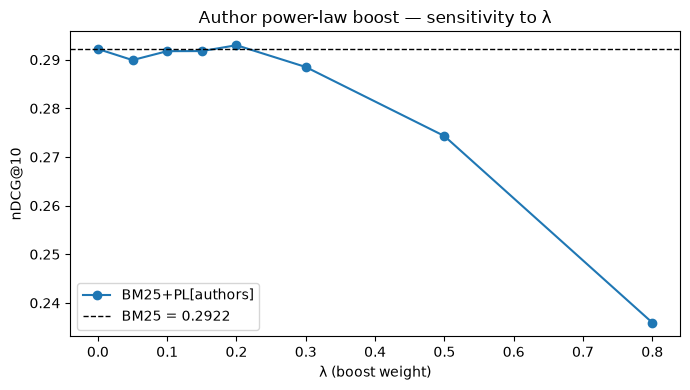

,lambda,ndcg_cut.10
0,0.00,0.2922
1,0.05,0.2899
2,0.10,0.2918
3,0.15,0.2918
4,0.20,0.2930
5,0.30,0.2885
6,0.50,0.2743
7,0.80,0.2359


In [4]:
lams = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 0.8]
sweep = pt.Experiment(
    [bm25_meta >> make_powerlaw_booster("authors", facet_df, n_docs, lam=l) for l in lams],
    topics, qrels, eval_metrics=[PRIMARY_METRIC], names=[f"λ={l}" for l in lams])
sweep["lambda"] = lams
bm25_score = base.mean()

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sweep["lambda"], sweep[PRIMARY_METRIC], "o-", label="BM25+PL[authors]")
ax.axhline(bm25_score, ls="--", c="black", lw=1, label=f"BM25 = {bm25_score:.4f}")
ax.set_xlabel("λ (boost weight)"); ax.set_ylabel("nDCG@10")
ax.set_title("Author power-law boost — sensitivity to λ"); ax.legend()
plt.tight_layout(); plt.show()
sweep[["lambda", PRIMARY_METRIC]].round(4)

## 3. Error analysis — where does the author boost help or hurt?

We sort the **per-query** nDCG@10 difference (`author boost − BM25`) and inspect the
extremes. This is the Stage-4 "look at retrieval errors / observe behaviour vs.
baseline" step.

In [5]:
delta = (pivot["BM25+PL[authors]"] - pivot["BM25"]).rename("delta")
err = (delta.to_frame()
            .merge(topics.set_index("qid"), left_index=True, right_index=True)
            .merge(pivot[["BM25", "BM25+PL[authors]"]], left_index=True, right_index=True)
            .sort_values("delta"))

print(f"queries improved: {(delta > 0).sum()} | unchanged: {(delta == 0).sum()} | "
      f"hurt: {(delta < 0).sum()}\n")
print("=== 5 topics the boost HELPED most ===")
display(err.tail(5)[["query", "BM25", "BM25+PL[authors]", "delta"]].iloc[::-1].round(3))
print("=== 5 topics the boost HURT most ===")
display(err.head(5)[["query", "BM25", "BM25+PL[authors]", "delta"]].round(3))

queries improved: 23 | unchanged: 56 | hurt: 21

=== 5 topics the boost HELPED most ===


,query,BM25,BM25+PL[authors],delta
qid,,,,
1c6ca51a558f678acf1b1d1a8b145f54,teacher and student relationship,0.369,0.519,0.150
7583b65656affbcc148b545b75dfc968,online food delivery services,0.123,0.239,0.116
2d885b04956ddd2e729af5d7e6f50384,relationship between student engagement and ac...,0.196,0.294,0.098
f9cfc9d84b800a51132ca858cc567e6e,supply chain covid 19,0.083,0.162,0.079
e874f77079e2943bfe8c7ab5985bba33,ai education,0.127,0.202,0.075


=== 5 topics the boost HURT most ===


,query,BM25,BM25+PL[authors],delta
qid,,,,
9c6556134c7d06548f65d0e363b69f44,leisure activities,0.429,0.123,-0.307
1a2f5d355af40cba5cc9ad1ffddd114e,pirineos,0.286,0.066,-0.220
1f50741d080a161ff0cde0b31cfd685e,extracurricular activities,0.363,0.288,-0.075
aaefb77ea38b942acc70b430c5a84078,disruptive students,0.854,0.786,-0.068
10fdb11b13fff4b822ddc239ad6f3969,vegetarian protein,0.599,0.539,-0.060


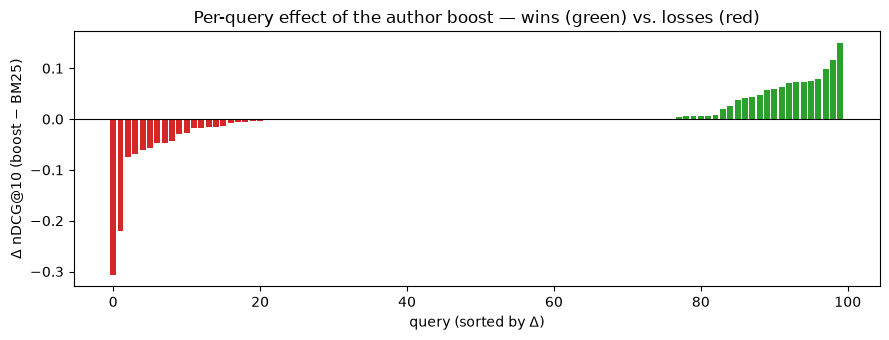

In [6]:
# distribution of per-query effects
fig, ax = plt.subplots(figsize=(9, 3.5))
d = delta.sort_values().values
ax.bar(range(len(d)), d, color=["tab:green" if x > 0 else "tab:red" for x in d])
ax.axhline(0, c="black", lw=0.8)
ax.set_xlabel("query (sorted by Δ)"); ax.set_ylabel("Δ nDCG@10 (boost − BM25)")
ax.set_title("Per-query effect of the author boost — wins (green) vs. losses (red)")
plt.tight_layout(); plt.show()

### Interpretation

The per-query chart explains the flat mean: the author boost is a **wash** — it lifts
a handful of queries and sinks a similar number. It helps when a query's top results
genuinely cluster around a few **rare, recurring authors** (a real topical signal);
it hurts when the most relevant paper has authors that appear nowhere else in the
result set, so the boost demotes it in favour of a prolific-but-off-topic author.
Because LongEval-Sci truncates to title+abstract and most authors are singletons (83 %
appear in exactly one document — see notebook 02), the EF signal is too thin to win
on average.

## 4. Conclusions

| Hypothesis | Prediction | Result |
|---|---|---|
| **H1** author boost improves nDCG@10 | helps (*p*<0.05) | **rejected** — change is tiny and not significant at any λ |
| **H2** pubyear boost (control) | hurts | **supported** — significant decrease |

**Takeaways & Remarks:** 
1) The negative control behaves exactly as theory predicts, which validates the experimental setup; 
2) The author EF×IDF boost is nDCG-neutral on this collection — an honest negative result, with a clear mechanism
(sparse author overlap in short scientific records);
3) The strongest *positive* lever we found is the simplest one: **tuning BM25's `b`/`k1`** (notebook 03);